###Dynamic Pricing Model – Airbnb Price Prediction (Aemf1 dataset)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor
from sklearn.linear_model import Ridge

##PART 1. Problem Definition (Introduction)
###Problem Statement
The objective of this project is to predict Airbnb listing price using city, room type, time (day), and demand/quality features. This is a simplified dynamic pricing prototype: it estimates what price level is typical given the listing characteristics.

##PART 2. Dataset Loading
We use the Aemf1 dataset (European cities Airbnb listings).

In [ ]:
df = pd.read_csv("/content/Aemf1.csv")
df

,City,Price,Day,Room Type,Shared Room,Private Room,Person Capacity,Superhost,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
0,Amsterdam,194.033698,Weekday,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473
1,Amsterdam,344.245776,Weekday,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928
2,Amsterdam,264.101422,Weekday,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700
3,Amsterdam,433.529398,Weekday,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565
4,Amsterdam,485.552926,Weekday,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41709,Vienna,715.938574,Weekend,Entire home/apt,False,False,6.0,False,0,1,10.0,100.0,3,0.530181,0.135447,219.402478,15.712158,438.756874,10.604584
41710,Vienna,304.793960,Weekend,Entire home/apt,False,False,2.0,False,0,0,8.0,86.0,1,0.810205,0.100839,204.970121,14.678608,342.182813,8.270427
41711,Vienna,637.168969,Weekend,Entire home/apt,False,False,2.0,False,0,0,10.0,93.0,1,0.994051,0.202539,169.073402,12.107921,282.296424,6.822996
41712,Vienna,301.054157,Weekend,Private room,False,True,2.0,False,0,0,10.0,87.0,1,3.044100,0.287435,109.236574,7.822803,158.563398,3.832416


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32050 entries, 0 to 32049
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   City                         32050 non-null  object 
 1   Price                        32050 non-null  float64
 2   Day                          32050 non-null  object 
 3   Room Type                    32050 non-null  object 
 4   Shared Room                  32050 non-null  bool   
 5   Private Room                 32050 non-null  bool   
 6   Person Capacity              32050 non-null  float64
 7   Superhost                    32050 non-null  bool   
 8   Multiple Rooms               32050 non-null  int64  
 9   Business                     32050 non-null  int64  
 10  Cleanliness Rating           32050 non-null  float64
 11  Guest Satisfaction           32050 non-null  float64
 12  Bedrooms                     32050 non-null  int64  
 13  City Center (km)

In [ ]:
df.dropna()

,City,Price,Day,Room Type,Shared Room,Private Room,Person Capacity,Superhost,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
0,Amsterdam,194.033698,Weekday,Private room,False,True,2.0,False,1,0,10.0,93.0,1,5.022964,2.539380,78.690379,4.166708,98.253896,6.846473
1,Amsterdam,344.245776,Weekday,Private room,False,True,4.0,False,0,0,8.0,85.0,1,0.488389,0.239404,631.176378,33.421209,837.280757,58.342928
2,Amsterdam,264.101422,Weekday,Private room,False,True,2.0,False,0,1,9.0,87.0,1,5.748312,3.651621,75.275877,3.985908,95.386955,6.646700
3,Amsterdam,433.529398,Weekday,Private room,False,True,4.0,False,0,1,9.0,90.0,2,0.384862,0.439876,493.272534,26.119108,875.033098,60.973565
4,Amsterdam,485.552926,Weekday,Private room,False,True,2.0,True,0,0,10.0,98.0,1,0.544738,0.318693,552.830324,29.272733,815.305740,56.811677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41709,Vienna,715.938574,Weekend,Entire home/apt,False,False,6.0,False,0,1,10.0,100.0,3,0.530181,0.135447,219.402478,15.712158,438.756874,10.604584
41710,Vienna,304.793960,Weekend,Entire home/apt,False,False,2.0,False,0,0,8.0,86.0,1,0.810205,0.100839,204.970121,14.678608,342.182813,8.270427
41711,Vienna,637.168969,Weekend,Entire home/apt,False,False,2.0,False,0,0,10.0,93.0,1,0.994051,0.202539,169.073402,12.107921,282.296424,6.822996
41712,Vienna,301.054157,Weekend,Private room,False,True,2.0,False,0,0,10.0,87.0,1,3.044100,0.287435,109.236574,7.822803,158.563398,3.832416


##PART 3. Data Cleaning & Preprocessing

In [ ]:
df.describe()

,Price,Person Capacity,Multiple Rooms,Business,Cleanliness Rating,Guest Satisfaction,Bedrooms,City Center (km),Metro Distance (km),Attraction Index,Normalised Attraction Index,Restraunt Index,Normalised Restraunt Index
count,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000,41714.000000
mean,260.094423,3.237235,0.295273,0.341180,9.442274,93.103179,1.165939,2.679792,0.603921,293.905990,11.719658,626.692618,25.553590
std,279.408493,1.299459,0.456171,0.474112,0.889173,8.141745,0.638157,1.996684,0.706206,235.750055,8.379161,520.644720,18.484572
min,34.779339,2.000000,0.000000,0.000000,2.000000,20.000000,0.000000,0.015045,0.002301,15.152201,0.926301,19.576924,0.592757
25%,144.016085,2.000000,0.000000,0.000000,9.000000,90.000000,1.000000,1.275913,0.236693,124.371614,5.510735,210.459574,11.132052
50%,203.819274,3.000000,0.000000,0.000000,10.000000,95.000000,1.000000,2.253237,0.391220,228.920599,9.951086,519.583509,21.814414
75%,297.373358,4.000000,1.000000,1.000000,10.000000,98.000000,1.000000,3.584489,0.678702,394.000201,15.467009,860.708156,36.821356
max,18545.450285,6.000000,1.000000,1.000000,10.000000,100.000000,10.000000,25.284557,14.273577,4513.563486,100.000000,6696.156772,100.000000


In [ ]:
df = df[df["Price"] > 0]
df.isnull().sum()


,0
City,0
Price,0
Day,0
Room Type,0
Shared Room,0
Private Room,0
Person Capacity,0
Superhost,0
Multiple Rooms,0
Business,0


##PART 4. Exploratory Data Analysis (EDA)
We show 6 simple visuals: price distribution, price by room type, price by city (top 10), price by Person Capacity,correlation matrix and a scatter plot.

In [ ]:
df_vis = df[df["Price"] <= 1000]
df_vis2 = df[df["Price"] <= 100]

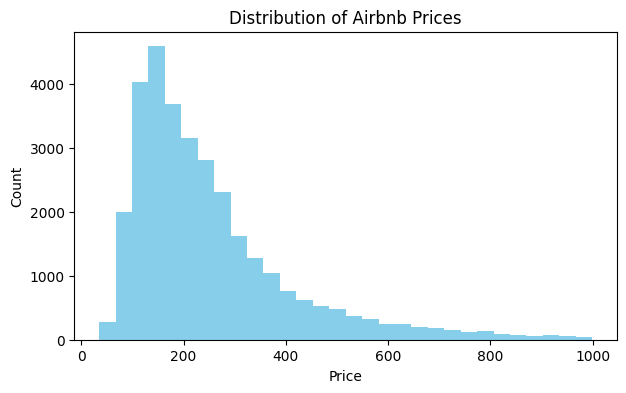

In [ ]:
plt.figure(figsize=(7,4))
plt.hist(df_vis["Price"], bins=30, color='skyblue')
plt.title("Distribution of Airbnb Prices")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

<Figure size 700x400 with 0 Axes>

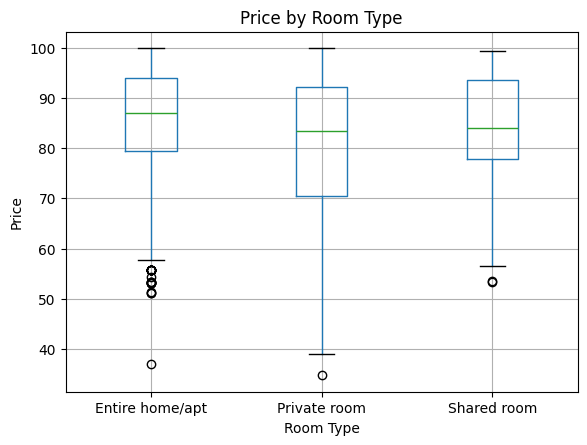

In [ ]:
plt.figure(figsize=(7,4))
df_vis2.boxplot(column="Price", by="Room Type")
plt.title("Price by Room Type")
plt.suptitle("")
plt.ylabel("Price")
plt.show()

<Figure size 700x400 with 0 Axes>

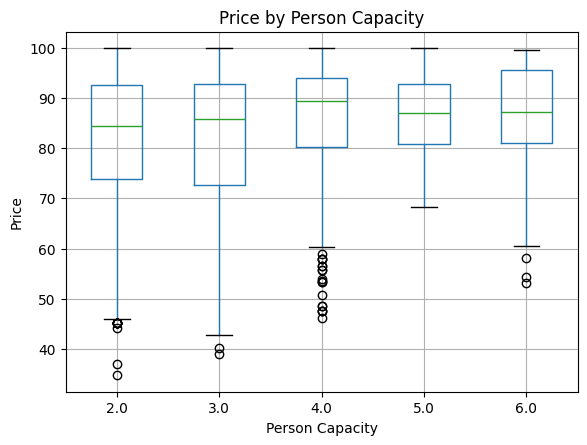

In [ ]:
plt.figure(figsize=(7,4))
df_vis2.boxplot(column="Price", by="Person Capacity")
plt.title("Price by Person Capacity")
plt.suptitle("")
plt.ylabel("Price")
plt.show()


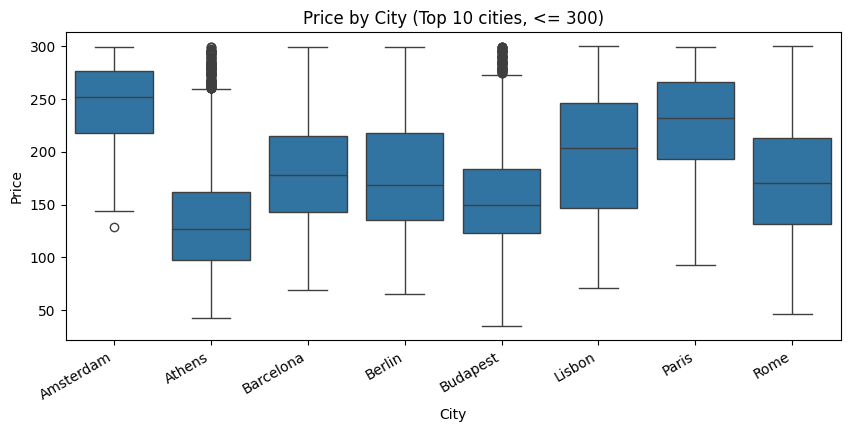

In [ ]:
df_vis2 = df[df["Price"] <= 300].copy()
top_cities = df["City"].value_counts().head(10).index
df_top = df_vis2[df_vis2["City"].isin(top_cities)].copy()

plt.figure(figsize=(10,4))
sns.boxplot(data=df_top, x="City", y="Price")
plt.title("Price by City (Top 10 cities, <= 300)")
plt.xlabel("City")
plt.ylabel("Price")
plt.xticks(rotation=30, ha="right")
plt.show()

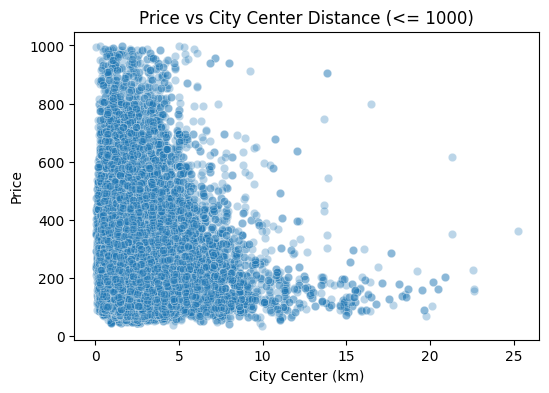

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(data=df_vis, x="City Center (km)", y="Price", alpha=0.3)
plt.title("Price vs City Center Distance (<= 1000)")
plt.xlabel("City Center (km)")
plt.ylabel("Price")
plt.show()

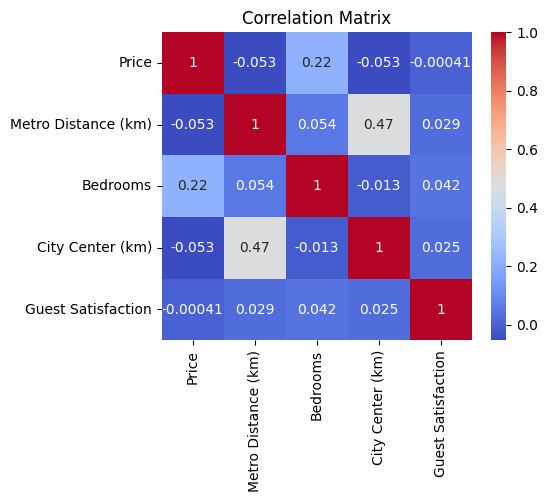

In [ ]:
plt.figure(figsize=(5,4))
sns.heatmap(df_vis[["Price","Metro Distance (km)","Bedrooms","City Center (km)","Guest Satisfaction"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

##PART 5. Data Preparation for Modeling
The target variable **Price** was log-transformed using log1p.  
Categorical features were converted into numerical values using one-hot encoding.  
The data was split into training and testing sets with an 80/20 ratio.


In [ ]:
y = np.log1p(df["Price"])
X = df.drop("Price", axis=1)
X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Part 6. Model Training and Evaluation

Three regression models were trained: Linear Regression, Ridge Regression, and XGBoost.

Models were trained on the log-transformed target variable. Predictions were converted back to the original scale using inverse logarithmic transformation expm1.

Model performance was evaluated using **RMSE** and **R² score**.  
XGBoost demonstrated the best performance with the lowest RMSE and highest R² value.


In [ ]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_test_real = np.expm1(y_test)
y_pred_lr_real = np.expm1(y_pred_lr)
rmse_lr_real = np.sqrt(mean_squared_error(y_test_real, y_pred_lr_real))
r2_lr = r2_score(y_test, y_pred_lr)

In [ ]:
xgb = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb.fit(X_train, y_train)
y_pred = xgb.predict(X_test)
y_pred_xgb_real = np.expm1(y_pred)
rmse_xgb_real = np.sqrt(mean_squared_error(y_test_real, y_pred_xgb_real))
r2_xgb = r2_score(y_test, y_pred)

In [ ]:
param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [100, 200],
    "learning_rate": [0.05, 0.1]
}

grid = GridSearchCV(
    XGBRegressor(objective="reg:squarederror", random_state=42),
    param_grid,
    cv=3,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_

In [ ]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
y_pred_real_ridge = np.expm1(y_pred_ridge)
rmse_ridge_real = np.sqrt(mean_squared_error(y_test_real, y_pred_real_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)

In [ ]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "XGBoost", "Ridge"],
    "RMSE": [rmse_lr_real, rmse_xgb_real, rmse_ridge_real],
    "R²": [r2_lr, r2_xgb, r2_ridge]
})

results


,Model,RMSE,R²
0,Linear Regression,277.874413,0.670453
1,XGBoost,270.289704,0.747229
2,Ridge,277.930814,0.670400


## Part 7. Challenger Model Selection and Hyperparameter Tuning

The best-performing model from the initial comparison was selected as the **Challenger model**.

To further improve performance, hyperparameter tuning was performed using **GridSearchCV** on the XGBoost regressor with 3-fold cross-validation.

The tuned model achieved a lower RMSE and higher R² score compared to the baseline models, confirming improved predictive performance.


In [ ]:
challenger = pd.DataFrame({
    "Model": ["Challenger (Best Boosting)"],
    "RMSE": [min(rmse_lr_real, rmse_xgb_real, rmse_ridge_real)],
    "R²": [max(r2_lr, r2_xgb, r2_ridge)]
})

challenger



,Model,RMSE,R²
0,Challenger (Best Boosting),270.289704,0.747229


In [ ]:
param_grid = {
    "max_depth": [3, 5],
    "n_estimators": [200, 400],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}

grid = GridSearchCV(
    XGBRegressor(objective="reg:squarederror", random_state=42),
    param_grid,
    cv=3,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

pred_best_log = best_model.predict(X_test)
pred_best_real = np.expm1(pred_best_log)

best_rmse = np.sqrt(mean_squared_error(y_test_real, pred_best_real))
best_r2 = r2_score(y_test, pred_best_log)

(best_rmse, best_r2, best_model.__class__.__name__)


(np.float64(265.1472107985021), 0.7589140677370763, 'XGBRegressor')

## Part 8. Final Prediction Function

A final prediction function was implemented to estimate accommodation prices.

The function takes raw user inputs, converts them into the same feature format used during model training, applies the trained XGBoost model, and returns the predicted price on the original scale.


In [ ]:
feature_columns = X.columns

def predict_price(
    city,
    day,
    room_type,
    person_capacity,
    superhost,
    multiple_rooms,
    business,
    cleanliness_rating,
    guest_satisfaction,
    bedrooms,
    city_center_km,
    metro_distance_km,
    attraction_index,
    normalised_attraction_index,
    restraunt_index,
    normalised_restraunt_index,
    shared_room=0,
    private_room=0
):
    row = pd.DataFrame(
        np.zeros((1, len(feature_columns))),
        columns=feature_columns
    )

    base_map = {
        "person_capacity": person_capacity,
        "superhost": int(superhost),
        "multiple_rooms": int(multiple_rooms),
        "business": int(business),
        "cleanliness_rating": cleanliness_rating,
        "guest_satisfaction": guest_satisfaction,
        "bedrooms": bedrooms,
        "city_center_km": city_center_km,
        "metro_distance_km": metro_distance_km,
        "attraction_index": attraction_index,
        "normalised_attraction_index": normalised_attraction_index,
        "restraunt_index": restraunt_index,
        "normalised_restraunt_index": normalised_restraunt_index,
        "shared_room": int(shared_room),
        "private_room": int(private_room),
    }

    for k, v in base_map.items():
        if k in row.columns:
            row.loc[0, k] = v

    for col in row.columns:
        if col == f"city_{city}":
            row.loc[0, col] = 1
        if col == f"day_{day}":
            row.loc[0, col] = 1
        if col == f"room_type_{room_type}":
            row.loc[0, col] = 1

    log_price = best_model.predict(row)[0]
    return float(np.expm1(log_price))
predict_price(
    city="Amsterdam",
    day="Weekday",
    room_type="Private room",
    person_capacity=2,
    superhost=0,
    multiple_rooms=0,
    business=0,
    cleanliness_rating=9,
    guest_satisfaction=500,
    bedrooms=1,
    city_center_km=2,
    metro_distance_km=0.5,
    attraction_index=100,
    normalised_attraction_index=30,
    restraunt_index=500,
    normalised_restraunt_index=50,
    shared_room=0,
    private_room=1
)


572.9030151367188